#**Автоматический градиент**

In [1]:
import torch

x = torch.tensor(1.0)
y = torch.tensor(2.0)

# w - параметр, который мы будем обучать -> requires_grad=True
w = torch.tensor(1.0, requires_grad=True)


In [2]:
# Forward шаг
y_predicted = w * x
loss = (y_predicted - y)**2
print(loss)


tensor(1., grad_fn=<PowBackward0>)


In [3]:
# backward шаг
loss.backward()
print(w.grad)


tensor(-2.)


In [4]:
# Обновление веса
with torch.no_grad():
    w -= 0.01 * w.grad
    print(w)
# не забываем обнулить градиенты
w.grad.zero_()

tensor(1.0200, requires_grad=True)


tensor(0.)

#**Линейная регрессия**

Дан набор данных точек $\{ (x_1, t_1), (x_2, t_2), \dots, (x_N, t_N) \}$, где каждая точка $(x_i, t_i)$ содержит *значение входа* $x_i$ и *значение выхода* $t_i$. 

Используем следующую  **модель**:
$$
y_i = wx_i + b
$$

Мы хотим, чтобы ответы $y_i$ были максимально близко к реальным значениям $t_i$. Для линейной регрессии мы используем квадрат ошибки для того, чтобы измерить расстояние (отличие) между $y_i$ и $t_i$. **loss function** для этого простого примера:
$$
\mathcal{L}(y_i,t_i) = \frac{1}{2} (y_i - t_i)^2
$$

**Cost function** - это средний loss (ошибка) на всем множестве данных:
$$
\mathcal{E}(w,b) = \frac{1}{N} \sum_{i=1}^N \mathcal{L}(y_i, t_i) = \frac{1}{N} \sum_{i=1}^N \frac{1}{2} \left(wx_i + b - t_i \right)^2
$$

Мы генерируем синтетические данные {(xi,ti)}  где  xi  равномерно распределено на интервале  [0,10]  а  ti  созданы с помощью уравнение ( w=4  и  b=10 ):
ti=4xi+10+ϵ 

Здесь,  ϵ∼N(0,2)  ( ϵ  получено из Гауссовского распределения со средним значением 0 и дисперсией 2). Шум вносит некоторые случайные колебания в данные, для имитации реальых данных, которые имеют исходную закономерность, но отдельные наблюдения искажены случайным шумом.

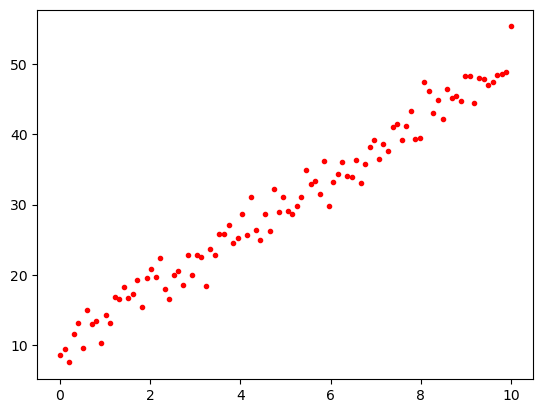

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt

N = 100  # Number of training data points
x = np.linspace(0, 10, N)

t = 4 * x + 10 + np.random.normal(0, 2, x.shape[0])
plt.plot(x, t, "r.")

x = torch.from_numpy(x)
t = torch.from_numpy(t)

In [6]:
params = {
    "w": torch.randn(1).requires_grad_(True),
    "b": torch.randn(1).requires_grad_(True),
}

# Регрессия: нейронные сети

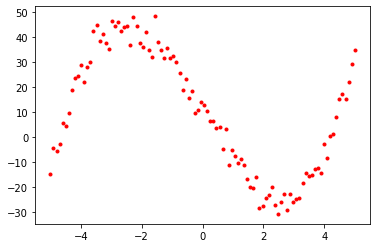

In [29]:
import numpy as np
x = np.linspace(-5, 5, 100)
t = x ** 3 - 20 * x + 10 + np.random.normal(0, 4, x.shape[0])
plt.plot(x, t, "r.")

x = torch.from_numpy(x).float()
t = torch.from_numpy(t)
